# Module 10: High Dynamic Range (HDR) Imaging
Standard digital displays and image formats are limited to 8-bits per color channel, meaning pixel brightness values can only range from 0 (pure black) to 255 (pure white). This limited scale creates a bottleneck when photographing high-contrast scenes—such as a dark room with a bright sunlit window. If you expose for the room, the window clips to solid white; if you expose for the window, the room drops into solid black. 

High Dynamic Range (HDR) imaging solves this by combining a sequence of photographs taken at different exposure times, capturing the full spectrum of details in both the deepest shadows and the brightest highlights.

### 1. Library Configurations
This block loads our primary image processing toolkit (`cv2`), array math utilities (`numpy`), and charting libraries (`matplotlib`). We include specialized image utilities from IPython to handle file previews inside our workspace environment.

In [1]:
# Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from zipfile import ZipFile
from urllib.request import urlretrieve

%matplotlib inline

In [2]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assests....", end="")

    # Downloading zip file using urllib package.
    urlretrieve(url, save_path)

    try:
        # Extracting zip file using the zipfile package.
        with ZipFile(save_path) as z:
            # Extract ZIP file contents in the same directory.
            z.extractall(os.path.split(save_path)[0])

        print("Done")

    except Exception as e:
        print("\nInvalid file.", e)
URL = r"https://www.dropbox.com/s/qa1hsyxt66pvj02/opencv_bootcamp_assets_NB10.zip?dl=1"

asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB10.zip")

# Download if assest ZIP does not exists.
if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)

### 2. Loading Multiple Bracketed Exposures
To build an HDR image, we need photographs of the exact same scene captured at different shutter speeds. 
* **The Dataset:** We load four pictures ranging from a very fast exposure (**1/30 seconds**—which captures details inside the hot, bright light bulb filament without blowing out) to a very long exposure (**15 seconds**—which uncovers the deep hidden textures in the dark background shadows).

In [3]:
def readImagesAndTimes():
    # List of file names
    filenames = ["img_0.033.jpg", "img_0.25.jpg", "img_2.5.jpg", "img_15.jpg"]

    # List of exposure times
    times = np.array([1 / 30.0, 0.25, 2.5, 15.0], dtype=np.float32)

    # Read images
    images = []
    for filename in filenames:
        im = cv2.imread(filename)
        images.append(im)

    return images, times

### 3. Image Alignment via Median Threshold Bitmaps (`cv2.createAlignMTB`)
Even if a camera is mounted on a sturdy tripod, pressing the shutter button or natural vibrations can cause tiny, sub-pixel shifts between bracketed shots. If we merge unaligned photos, the final HDR image will have blurry halos around the edges (called "ghosting").
* **How it works:** We initialize the MTB (Median Threshold Bitmap) alignment engine. It converts the images into simple binary black-and-white grids based on their median pixel values and shifts them mathematically to line up perfectly.


In [4]:
# Read images and exposure times
images, times = readImagesAndTimes()

# Align Images
alignMTB = cv2.createAlignMTB()
alignMTB.process(images, images)

### 4. Calibrating the Camera Response Function (CRF)
Camera sensors do not record light in a simple, linear fashion. If a scene gets twice as bright, the camera's internal software intentionally curves the pixel outputs so the resulting photograph looks more natural and pleasing to human eyes. To create a true physical map of light, we must reverse-engineer and undo this digital distortion.

* **How it works:** We use the **Debevec** algorithm to inspect how the pixel values change across our four different exposure times. It outputs a lookup graph showing exactly how the camera curves the colors Red, Green, and Blue.


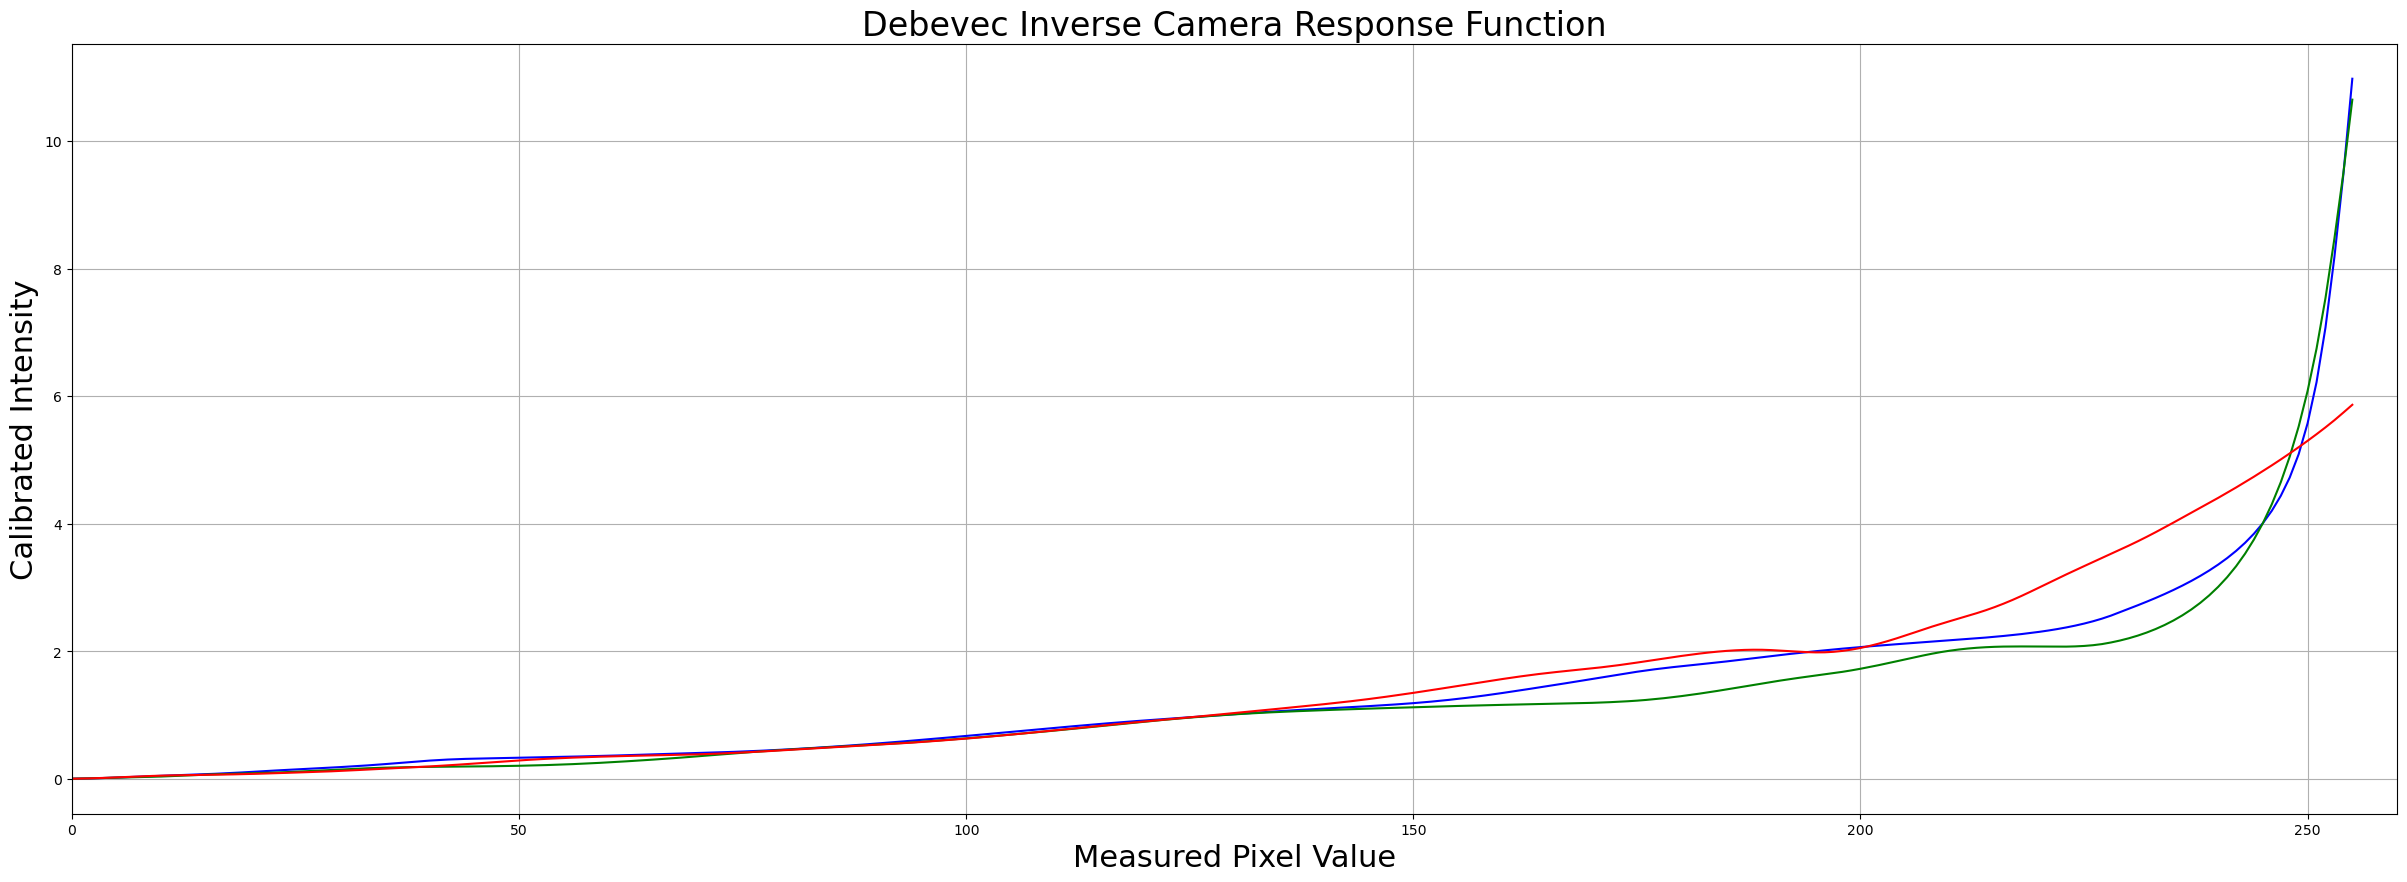

In [5]:
# Find Camera Response Function (CRF)
calibrateDebevec = cv2.createCalibrateDebevec()
responseDebevec = calibrateDebevec.process(images, times)

# Plot CRF
x = np.arange(256, dtype=np.uint8)
y = np.squeeze(responseDebevec)

ax = plt.figure(figsize=(30, 10))
plt.title("Debevec Inverse Camera Response Function", fontsize=24)
plt.xlabel("Measured Pixel Value", fontsize=22)
plt.ylabel("Calibrated Intensity", fontsize=22)
plt.xlim([0, 260])
plt.grid()
plt.plot(x, y[:, 0], "b", x, y[:, 1], "g", x, y[:, 2], "r")

### 5. Merging Exposures into a 32-Bit Linear Matrix
Now that the images are aligned and we have our color calibration map, we merge the four exposures into a single master image file.
* The output (`hdrDebevec`) is a **32-bit floating-point image array**. It does not clip at 255; instead, it stores the true physical light intensity values of the scene.

In [6]:
# Merge images into an HDR linear image
mergeDebevec = cv2.createMergeDebevec()
hdrDebevec = mergeDebevec.process(images, times, responseDebevec)

### 6. Tonemapping: Compressing 32-Bit Data for Standard Screens
Standard computer screens and JPEG files cannot read or display a 32-bit HDR image.
**Tonemapping** is the process of compressing this massive range of light data back down into a standard 8-bit format without losing the brilliant highlights or deep shadow details.

We test three famous mathematical approaches to see how they handle contrast:

1. **Drago's Method:** Uses a logarithmic scale to compress colors. It mimics human vision preservation and gives a very realistic, balanced look.

2. **Reinhard's Method:** Uses a global intensity transfer function based on photographic scales.

3. **Mantiuk's Method:** A highly stylized algorithm that focuses heavily on sharpening structural edges and visual contrast, though it can occasionally create wild, saturated colors if turned up too high.

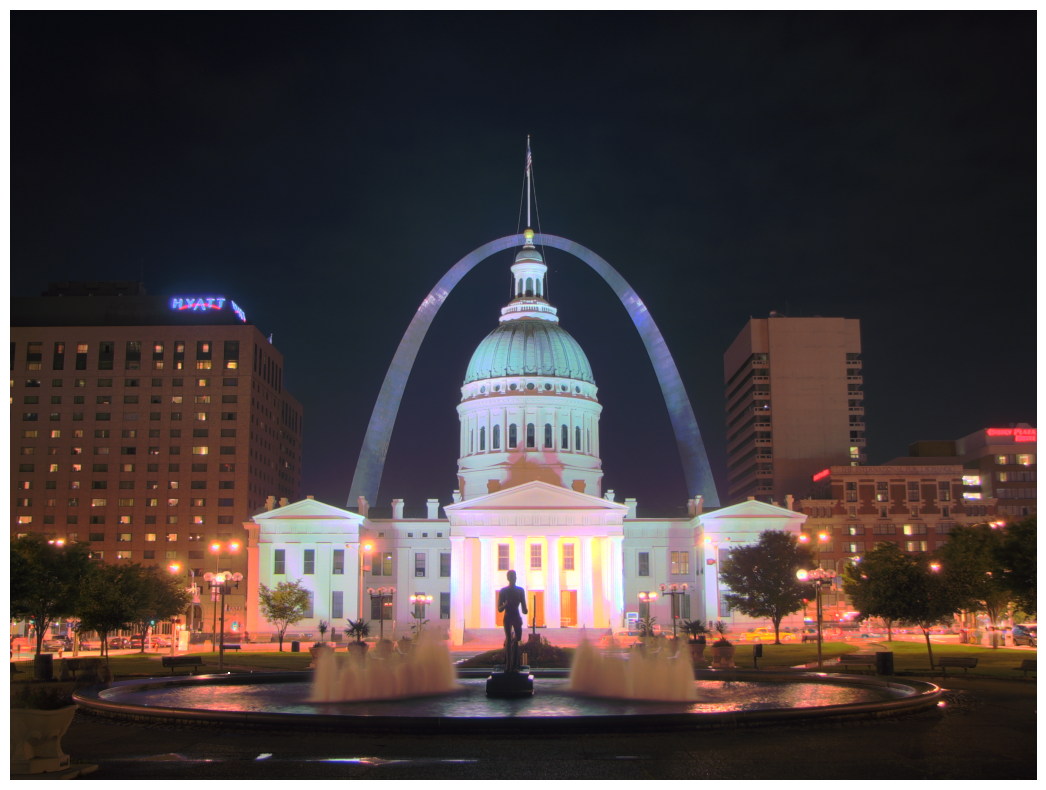

In [7]:
# Tonemap using Drago's method to obtain 24-bit color image
tonemapDrago = cv2.createTonemapDrago(1.0, 0.7)
ldrDrago = tonemapDrago.process(hdrDebevec)
ldrDrago = 3 * ldrDrago

# Saving image
cv2.imwrite("ldr-Drago.jpg", 255*ldrDrago)

# Plotting image
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrDrago, 0, 1)[:,:,::-1]);plt.axis("off");

Tonemaping using Reinhard's method ... 


(np.float64(-0.5), np.float64(2815.5), np.float64(2111.5), np.float64(-0.5))

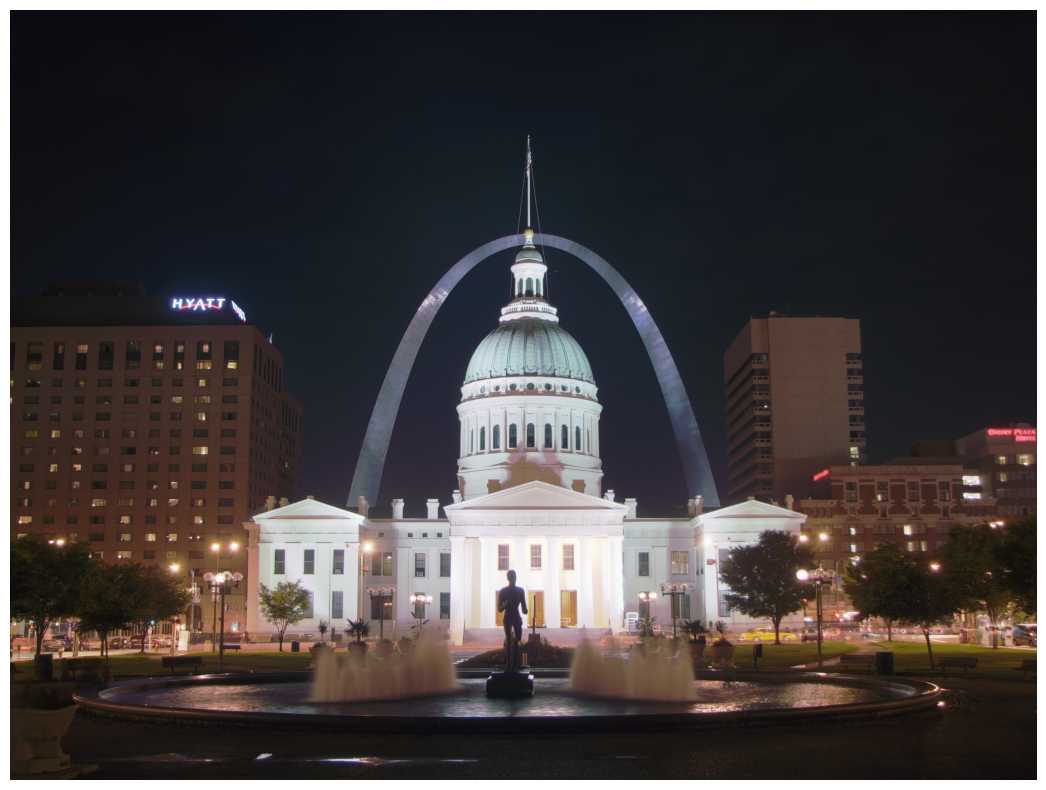

In [8]:
# Tonemap using Reinhard's method to obtain 24-bit color image
print("Tonemaping using Reinhard's method ... ")
tonemapReinhard = cv2.createTonemapReinhard(1.5, 0, 0, 0)
ldrReinhard = tonemapReinhard.process(hdrDebevec)

# Saving image
cv2.imwrite("ldr-Reinhard.jpg", ldrReinhard * 255)

# Plotting image
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrReinhard, 0, 1)[:,:,::-1]);plt.axis("off")

Tonemaping using Mantiuk's method ... 


(np.float64(-0.5), np.float64(2815.5), np.float64(2111.5), np.float64(-0.5))

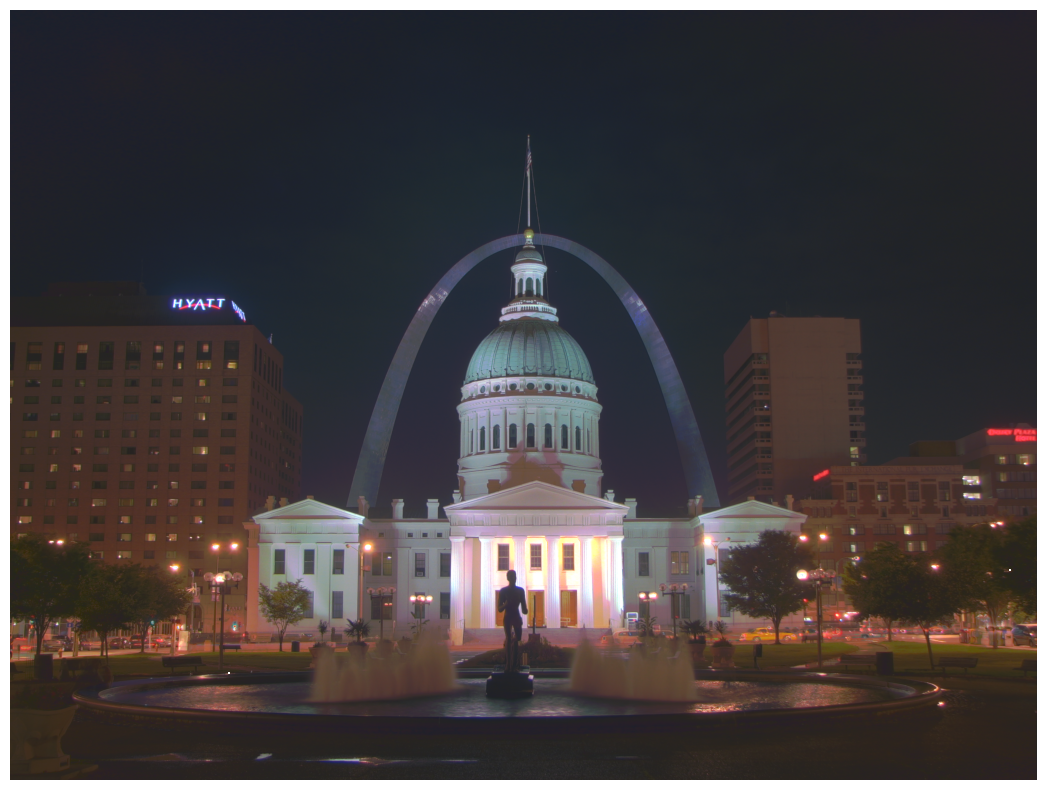

In [9]:
# Tonemap using Mantiuk's method to obtain 24-bit color image
print("Tonemaping using Mantiuk's method ... ")
tonemapMantiuk = cv2.createTonemapMantiuk(2.2, 0.85, 1.2)
ldrMantiuk = tonemapMantiuk.process(hdrDebevec)
ldrMantiuk = 3 * ldrMantiuk

# save the image using cv2.imwrite
cv2.imwrite("ldr-Mantiuk.jpg", ldrMantiuk * 255)

# plot the image using plt.imshow
plt.figure(figsize=(20, 10));plt.imshow(np.clip(ldrMantiuk, 0, 1)[:,:,::-1]);plt.axis("off")